# Etapa 3 - Análise Exploratória e Consultas SQL

**Objetivo:** Compreender os dados através de análises estatísticas e consultas SQL que respondam às perguntas de pesquisa, garantindo que os dados estejam em formato adequado para análise.

**Perguntas de pesquisa:**
1. Existem padrões sazonais nas exportações brasileiras ao longo dos meses de 2025 em relação ao volume exportado (`net_weight_kg`) e ao valor da exportação (`fob_value_usd`)?
2. É possível classificar a via de transporte principal (`transport_route`) com base em `net_weight_kg`, `origin_state` e `fob_value_usd`?

## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style='whitegrid')

## Carregando o Dataset Limpo

In [3]:
df = pd.read_csv('../data/cleaned_exports_2025.csv')
print(f'Shape: {df.shape}')
df.dtypes

Shape: (1709746, 23)


year                              int64
month                             int64
ncm_code                          int64
statistical_unit_code_export      int64
country_code                      int64
origin_state                        str
transport_route                   int64
urf_code                          int64
statistical_quantity              int64
net_weight_kg                     int64
fob_value_usd                     int64
month_name                          str
value_per_kg                    float64
quarter                           int64
semester                          int64
origin_region                       str
ncm_chapter                       int64
is_mercosul                       int64
is_coastal_state                  int64
is_express_delivery               int64
statistical_unit_code_ncm         int64
ncm_name_ptbr                       str
country_name                        str
dtype: object

In [4]:
df.head()

,year,month,ncm_code,statistical_unit_code_export,country_code,origin_state,transport_route,urf_code,statistical_quantity,net_weight_kg,fob_value_usd,month_name,value_per_kg,quarter,semester,origin_region,ncm_chapter,is_mercosul,is_coastal_state,is_express_delivery,statistical_unit_code_ncm,ncm_name_ptbr,country_name
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203,Aug,15.615385,3,2,South,71,0,1,0,19,"Outras pedras preciosas (exceto diamantes) ou semipreciosas, trabalhadas de outro modo",El Salvador
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324,Dec,1.327894,4,2,South,2,0,1,0,10,"Coxas com sobrecoxas não desossadas de galinha, comestíveis, congelados",Singapura
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012,Nov,29.232404,4,2,Southeast,33,0,1,0,10,Outras preparações capilares,Suíça
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458,Nov,3.470661,4,2,Southeast,56,0,1,0,10,"Falsos tecidos de poliéster, de peso superior a 70 g/m2 mas não superior a 150 g/m2",Uruguai
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304,Jun,3.605000,2,1,Southeast,21,0,1,0,10,Outras preparações alimentícias,Indonésia


## Preparação dos Dados em Formato Tidy

In [5]:
print('Colunas disponíveis:')
print(df.columns.tolist())

key_cols = ['year', 'month', 'ncm_code', 'country_code', 'origin_state', 'transport_route', 'urf_code']
n_dup = df.duplicated(subset=key_cols).sum()
print(f'\nLinhas duplicadas (chave composta): {n_dup}')

nulos = df.isnull().sum()
print(f'\nColunas com valores nulos:')
print(nulos[nulos > 0])

Colunas disponíveis:
['year', 'month', 'ncm_code', 'statistical_unit_code_export', 'country_code', 'origin_state', 'transport_route', 'urf_code', 'statistical_quantity', 'net_weight_kg', 'fob_value_usd', 'month_name', 'value_per_kg', 'quarter', 'semester', 'origin_region', 'ncm_chapter', 'is_mercosul', 'is_coastal_state', 'is_express_delivery', 'statistical_unit_code_ncm', 'ncm_name_ptbr', 'country_name']



Linhas duplicadas (chave composta): 0

Colunas com valores nulos:
value_per_kg     130840
origin_region      5350
dtype: int64


O dataset já satisfaz os princípios 1 e 2: cada coluna representa uma variável distinta (sem formato wide), e cada linha é uma operação de exportação única. Os valores nulos esperados estão em `value_per_kg`, registros com `net_weight_kg = 0` não têm valor por kg calculável, o que faz sentido.

### Ajuste de Tipos

In [6]:
# Numéricos contínuos para float
df['net_weight_kg'] = df['net_weight_kg'].astype(float)
df['fob_value_usd'] = df['fob_value_usd'].astype(float)

# Flags binárias para bool
for col in ['is_mercosul', 'is_coastal_state', 'is_express_delivery']:
    df[col] = df[col].astype(bool)

# transport_route como string para compatibilidade com TRANSPORT_NAMES
df['transport_route'] = df['transport_route'].astype(str)

print('Tipos ajustados:')
print(df[['net_weight_kg', 'fob_value_usd', 'transport_route',
          'is_mercosul', 'is_coastal_state', 'is_express_delivery']].dtypes)

Tipos ajustados:
net_weight_kg          float64
fob_value_usd          float64
transport_route            str
is_mercosul               bool
is_coastal_state          bool
is_express_delivery       bool
dtype: object


### Exportação para Parquet

In [7]:
os.makedirs('../results', exist_ok=True)
PARQUET_PATH = '../results/exports_tidy.parquet'
df.to_parquet(PARQUET_PATH, index=False, engine='pyarrow')
print(f'Dataset exportado para {PARQUET_PATH}')
print(f'Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

Dataset exportado para ../results/exports_tidy.parquet
Shape: 1,709,746 linhas × 23 colunas


## Consultas SQL Analíticas

Todas as consultas são executadas diretamente sobre o arquivo Parquet via API Python do DuckDB.

In [8]:
PARQUET_PATH = '../results/exports_tidy.parquet'

MONTH_ORDER = ['Jan', 'Fev', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

VIAS_PATH = '../data/codigo_vias.csv'
if os.path.exists(VIAS_PATH):
    vias_df = pd.read_csv(VIAS_PATH, sep=';', encoding='latin1')
    vias_df['CO_VIA'] = vias_df['CO_VIA'].astype(str).str.strip().str.lstrip('0').replace('', '0')
    TRANSPORT_NAMES = dict(zip(vias_df['CO_VIA'], vias_df['NO_VIA'].str.strip().str.title()))
    print(f'Nomes das vias carregados de {VIAS_PATH} ({len(TRANSPORT_NAMES)} entradas)')
else:
    TRANSPORT_NAMES = {
        '0': 'Não Definida', '1': 'Marítima', '2': 'Fluvial', '3': 'Lacustre',
        '4': 'Aérea', '5': 'Postal', '6': 'Ferroviária', '7': 'Rodoviária',
        '8': 'Conduto/Oleoduto', '9': 'Meios Próprios', '11': 'Courier',
        '12': 'Em Mãos', '13': 'Por Reboque', '14': 'Dutos', '15': 'Vicinal Fronteiriço'
    }
    print('Usando dicionário padrão (codigo_vias.csv não encontrado)')

main_routes = [TRANSPORT_NAMES[c] for c in ['1', '4', '7', '15'] if c in TRANSPORT_NAMES]
print(f'\nTRANSPORT_NAMES: {TRANSPORT_NAMES}')
print(f'main_routes: {main_routes}')

Nomes das vias carregados de ../data/codigo_vias.csv (17 entradas)

TRANSPORT_NAMES: {'10': 'Entrada/Saida Ficta', '99': 'Via Desconhecida', '13': 'Por Reboque', '11': 'Courier', '15': 'Vicinal Fronteirico', '14': 'Dutos', '12': 'Em Maos', '0': 'Via Nao Declarada', '1': 'Maritima', '2': 'Fluvial', '3': 'Lacustre', '4': 'Aerea', '5': 'Postal', '6': 'Ferroviaria', '7': 'Rodoviaria', '8': 'Conduto/Rede De Transmissao', '9': 'Meios Proprios'}
main_routes: ['Maritima', 'Aerea', 'Rodoviaria', 'Vicinal Fronteirico']


### Consulta 1 - Sazonalidade Mensal

Volume total exportado (`net_weight_kg`) e valor total (`fob_value_usd`) agregados por mês, para verificar se há concentração em períodos específicos do ano (H1).

In [9]:
q1 = duckdb.sql(f"""
    SELECT
        month,
        month_name,
        SUM(net_weight_kg)  AS total_weight_kg,
        SUM(fob_value_usd)  AS total_fob_usd,
        COUNT(*)            AS n_records
    FROM '{PARQUET_PATH}'
    GROUP BY month, month_name
    ORDER BY month
""").df()

q1['month_name'] = pd.Categorical(q1['month_name'], categories=MONTH_ORDER, ordered=True)
q1 = q1.sort_values('month_name')
q1

,month,month_name,total_weight_kg,total_fob_usd,n_records
0,1,Jan,6.058448e+10,2.539823e+10,126606
1,2,Fev,5.162463e+10,2.275395e+10,123298
2,3,Mar,6.501193e+10,2.872587e+10,142295
3,4,Apr,6.934182e+10,2.988613e+10,141626
4,5,May,7.433577e+10,2.992008e+10,139153
5,6,Jun,7.401544e+10,2.903625e+10,141901
6,7,Jul,8.182067e+10,3.212863e+10,151721
7,8,Aug,8.135579e+10,2.955863e+10,143937
8,9,Sep,7.575947e+10,3.048676e+10,148403
9,10,Oct,8.068969e+10,3.150886e+10,152457


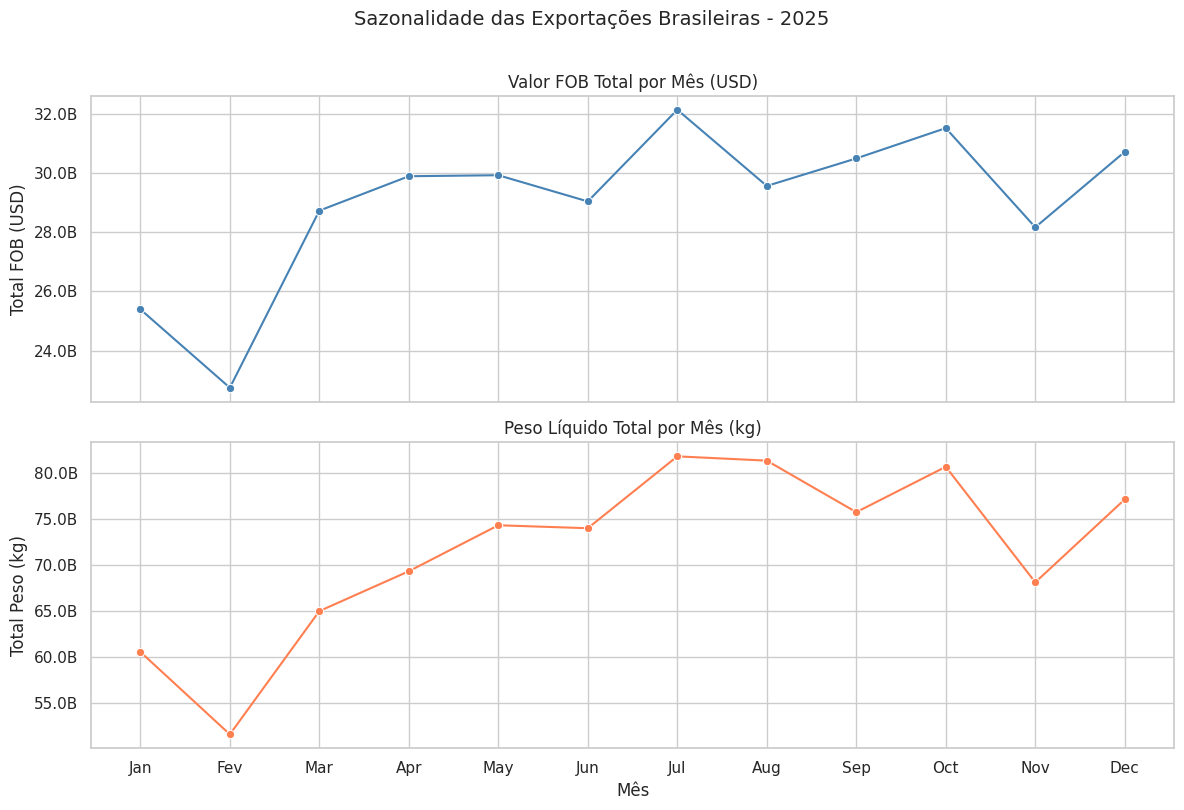

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=q1, x='month_name', y='total_fob_usd', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Valor FOB Total por Mês (USD)')
axes[0].set_ylabel('Total FOB (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

sns.lineplot(data=q1, x='month_name', y='total_weight_kg', marker='o', ax=axes[1], color='coral')
axes[1].set_title('Peso Líquido Total por Mês (kg)')
axes[1].set_ylabel('Total Peso (kg)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].set_xlabel('Mês')

plt.suptitle('Sazonalidade das Exportações Brasileiras - 2025', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/q1_sazonalidade_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 1: Sazonalidade Mensal

No primeiro gráfico (azul), o valor FOB total por mês oscila entre ~23 bilhões de USD (mínimo em fevereiro) e ~32 bilhões (pico em julho). No segundo gtáfico (coral), o peso líquido total segue padrão semelhante: mínimo em fevereiro (~52 bilhões de kg) e pico em julho (~82 bilhões de kg). Ambas as curvas mostram um vale (queda) claro em fevereiro, crescimento progressivo até julho, e uma leve queda em novembro seguida de recuperação em dezembro.

Esse padrão assimétrico, com fevereiro bastante abaixo e julho/outubro acima, fornece evidência de que volume e valor não se distribuem uniformemente ao longo do ano, o que apoia diretamente a Hipótese 1. A queda em fevereiro (mês mais curto do ano, com menos dias úteis) e o pico em julho são consistentes com o ciclo de exportação de commodities agrícolas como soja e milho, onde a safra é colhida no primeiro semestre e transprtada e comercializada nos meses seguintes.

### Consulta 2 - Top 10 Produtos Exportados (por Valor FOB)

Os produtos com maior geração de receita em exportações, identificados pelo nome NCM em português.

In [11]:
q2 = duckdb.sql(f"""
    SELECT
        ncm_chapter,
        ncm_name_ptbr,
        SUM(fob_value_usd)  AS total_fob_usd,
        SUM(net_weight_kg)  AS total_weight_kg,
        COUNT(*)            AS n_records
    FROM '{PARQUET_PATH}'
    GROUP BY ncm_chapter, ncm_name_ptbr
    ORDER BY total_fob_usd DESC
    LIMIT 10
""").df()

q2

,ncm_chapter,ncm_name_ptbr,total_fob_usd,total_weight_kg,n_records
0,27,Óleos brutos de petróleo,4.453616e+10,9.819364e+10,412
1,12,"Soja, mesmo triturada, exceto para semeadura",4.353159e+10,1.081776e+11,1931
2,26,"Minérios de ferro e seus concentrados, exceto as piritas de ferro ustuladas (cinzas de piritas), não aglomerados",2.629091e+10,3.924169e+11,510
3,9,"Café não torrado, não descafeinado, em grão",1.486544e+10,2.269000e+09,3753
4,2,"Carnes desossadas de bovino, congeladas",1.440630e+10,2.727377e+09,9920
5,17,Outros açúcares de cana,1.207989e+10,2.945627e+10,1793
6,47,"Pastas químicas de madeira, à soda ou ao sulfato, exceto pastas para dissolução, semibranqueadas ou branqueadas, de não coníferas",8.939119e+09,2.041227e+10,1450
7,10,"Milho em grão, exceto para semeadura",8.449220e+09,4.094783e+10,1971
8,27,Fuel oil,7.006597e+09,1.502613e+10,1513
9,23,"Bagaços e outros resíduos sólidos, da extração do óleo de soja",5.991809e+09,1.809253e+10,862


/tmp/ipykernel_70509/3603092448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q2, y='ncm_short', x='total_fob_usd', palette='Blues_r', ax=ax)


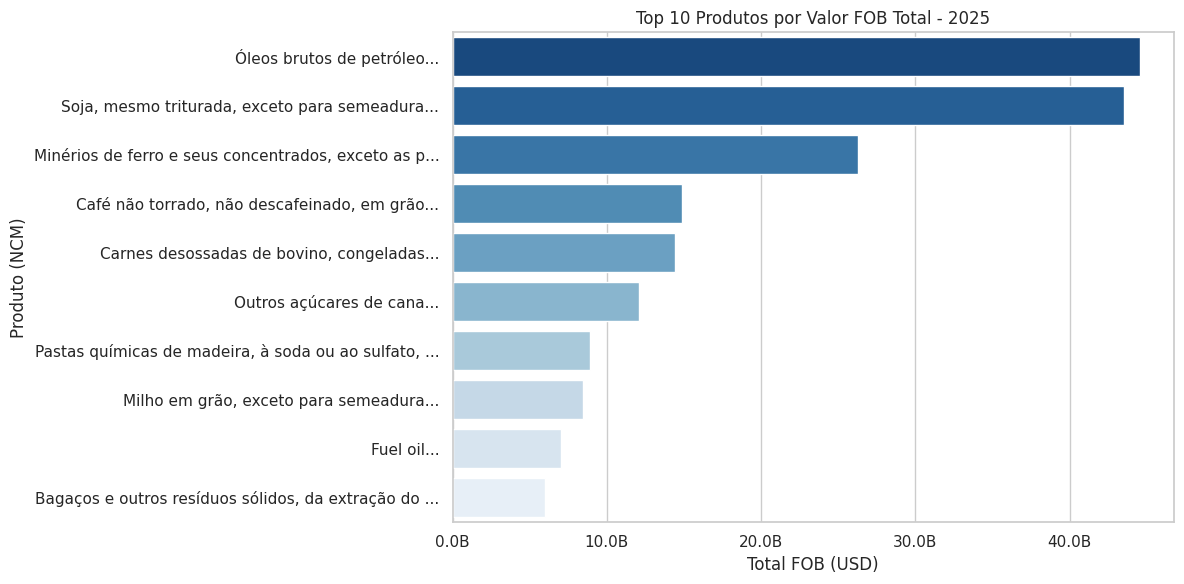

In [12]:
q2['ncm_short'] = q2['ncm_name_ptbr'].str[:50] + '...'

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=q2, y='ncm_short', x='total_fob_usd', palette='Blues_r', ax=ax)
ax.set_title('Top 10 Produtos por Valor FOB Total - 2025')
ax.set_xlabel('Total FOB (USD)')
ax.set_ylabel('Produto (NCM)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('../results/q2_top10_produtos.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 2: Top 10 Produtos Exportados

O gráfico de barras horizontais apresenta os produtos em ordem decrescente de valor FOB. Óleos brutos de petróleo e soja triturada lideram quase que empatados, com  aproximadamente 44 bilhões de USD cada. O terceiro lugar, minérios de ferro, alcança cerca de 26 bilhões. A partir do quarto produto (Café, ~15 bilhões), os valores caem consideravelmente. Os últimos itens do ranking (pastas químicas, milho em grão, combustível e bagaços/resíduos de soja) ficam abaixo de 10 bilhões cada. Essa curva acentuada mostra a alta concentração de receita nos três primeiros produtos (NCM).

Todos os 10 produtos são commodities primárias ou semielaboradas (petróleo, grãos, minério, carne, celulose), o que caracteriza bem a pauta exportadora brasileira em 2025. Para a Pergunta 1, esse resultado indica que a sazonalidade das exportações é fortemente influenciada pelo ciclo de produção desses produtos agrícolas. Especialmente soja e milho, pois suas colheitas, transporte e comercialização, como dito anteriormente, são realizadas periodicamente contribuindo para o padrão de picos identificado na Consulta 1.

### Consulta 3 - Top 10 Países Destino (por Valor FOB)

Os maiores parceiros comerciais do Brasil em 2025 por receita gerada.

In [13]:
q3 = duckdb.sql(f"""
    SELECT
        country_name,
        is_mercosul,
        SUM(fob_value_usd)  AS total_fob_usd,
        SUM(net_weight_kg)  AS total_weight_kg,
        COUNT(*)            AS n_records
    FROM '{PARQUET_PATH}'
    GROUP BY country_name, is_mercosul
    ORDER BY total_fob_usd DESC
    LIMIT 10
""").df()

q3

,country_name,is_mercosul,total_fob_usd,total_weight_kg,n_records
0,China,False,9.994024e+10,4.517368e+11,29606
1,Estados Unidos,False,3.768225e+10,3.843174e+10,97777
2,Argentina,False,1.810530e+10,8.396711e+09,107737
3,Países Baixos (Holanda),False,1.172674e+10,2.563157e+10,18685
4,Espanha,False,8.783248e+09,1.765941e+10,14716
5,México,False,7.728867e+09,6.122795e+09,49446
6,Singapura,False,7.353097e+09,1.110200e+10,40541
7,Canadá,False,7.251871e+09,7.731563e+09,11866
8,Chile,False,7.176227e+09,5.834671e+09,69392
9,Índia,False,6.865881e+09,1.692422e+10,14558


/tmp/ipykernel_70509/2701014019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q3, y='country_name', x='total_fob_usd', palette=palette, ax=ax)


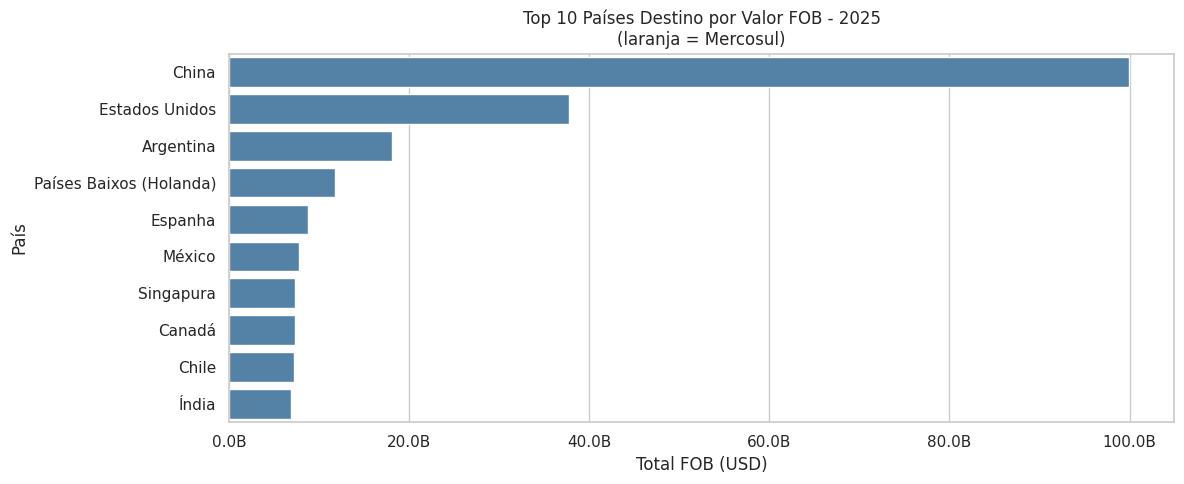

In [14]:
palette = ['#e07b54' if m else 'steelblue' for m in q3['is_mercosul']]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=q3, y='country_name', x='total_fob_usd', palette=palette, ax=ax)
ax.set_title('Top 10 Países Destino por Valor FOB - 2025\n(laranja = Mercosul)')
ax.set_xlabel('Total FOB (USD)')
ax.set_ylabel('País')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('../results/q3_top10_paises.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 3: Top 10 Países Destino

A China domina amplamente com ~100 bilhões de USD, mais do que o dobro do segundo colocado, Estados Unidos (~38 bilhões). A Argentina aparece em terceiro (~18 bilhões), seguida por Países Baixos (~12 bilhões). Os demais países (Espanha, México, Singapura, Canadá, Chile, Índia) têm valores similares, entre 6 e 9 bilhões. Todas as barras aparecem em azul exceto a Argentina identificada pelo campo `is_mercosul` como membro do bloco.

A enorme concentração de exportações para a China, a principal compradora de soja e minério de ferro brasileiro, dialoga diretamente com os produtos identificados na Consulta 2. Para a Pergunta 1, isso é relevante porque exportações para a China são realizadas em grandes volumes por via marítima, criando sazonalidade atrelada à demanda do mercado asiático.

### Consulta 4 - Modalidade de Transporte por Região de Origem

Distribuição de registros, peso médio e valor médio por via de transporte e região de origem, rankeado por fob_value_usd médio.

In [15]:
q4 = duckdb.sql(f"""
    WITH base AS (
        SELECT
            transport_route,
            origin_region,
            COUNT(*)                    AS n_records,
            MEDIAN(net_weight_kg)       AS median_weight_kg,
            MEDIAN(fob_value_usd)       AS median_fob_usd,
            SUM(fob_value_usd)          AS total_fob_usd
        FROM '{PARQUET_PATH}'
        WHERE origin_region IS NOT NULL
        GROUP BY transport_route, origin_region
    )
    SELECT
        *,
        RANK() OVER (PARTITION BY origin_region ORDER BY total_fob_usd DESC) AS rank_by_fob
    FROM base
    ORDER BY origin_region, rank_by_fob
""").df()

q4['transport_name'] = q4['transport_route'].astype(str).map(TRANSPORT_NAMES)
q4.head(20)

,transport_route,origin_region,n_records,median_weight_kg,median_fob_usd,total_fob_usd,rank_by_fob,transport_name
0,1,Central-West,25811,51974.0,94906.0,5.193627e+10,1,Maritima
1,4,Central-West,4582,12.0,1484.5,1.052839e+09,2,Aerea
2,7,Central-West,6127,942.0,5150.0,9.891866e+08,3,Rodoviaria
3,2,Central-West,58,65027086.5,7327822.5,5.713586e+08,4,Fluvial
4,0,Central-West,180,8838.0,6595.5,1.445724e+08,5,Via Nao Declarada
5,3,Central-West,13,2518691.0,656918.0,2.966911e+07,6,Lacustre
6,9,Central-West,2,8233.5,1789380.5,3.578761e+06,7,Meios Proprios
7,6,Central-West,67,120182.0,34401.0,3.232940e+06,8,Ferroviaria
8,15,Central-West,258,35.0,438.0,2.829850e+05,9,Vicinal Fronteirico
9,12,Central-West,2,0.0,35189.0,7.037800e+04,10,Em Maos


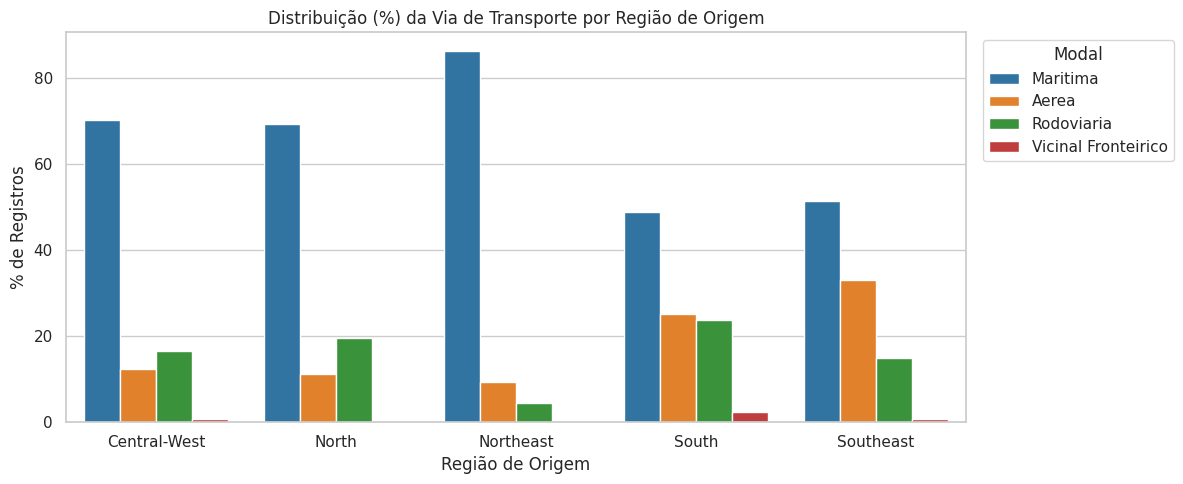

In [16]:
q4_top = q4[q4['transport_name'].isin(main_routes)].copy()
totals = q4_top.groupby('origin_region')['n_records'].transform('sum')
q4_top['pct'] = q4_top['n_records'] / totals * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=q4_top, x='origin_region', y='pct', hue='transport_name',
            hue_order=main_routes, palette='tab10', ax=ax)
ax.set_title('Distribuição (%) da Via de Transporte por Região de Origem')
ax.set_xlabel('Região de Origem')
ax.set_ylabel('% de Registros')
ax.legend(title='Modal', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/q4_modal_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_70509/3154347687.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q4_med, x='transport_name', y=col,
/tmp/ipykernel_70509/3154347687.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q4_med, x='transport_name', y=col,


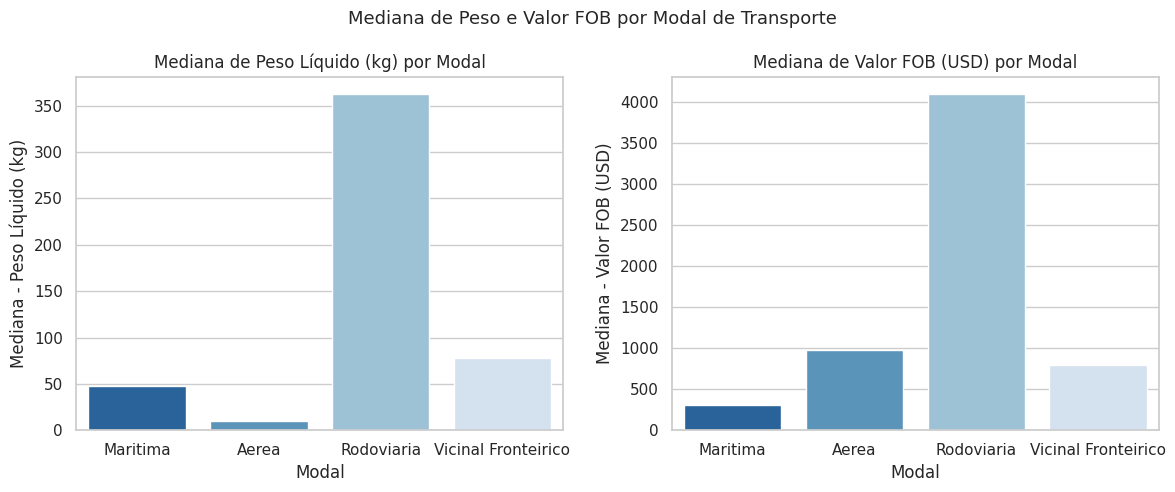

In [17]:
q4_med = duckdb.sql(f"""
    SELECT
        transport_route,
        MEDIAN(net_weight_kg) AS median_weight_kg,
        MEDIAN(fob_value_usd) AS median_fob_usd
    FROM '{PARQUET_PATH}'
    WHERE transport_route IN ('1', '4', '7', '15')
    GROUP BY transport_route
""").df()
q4_med['transport_name'] = q4_med['transport_route'].astype(str).map(TRANSPORT_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, ylabel in zip(
    axes,
    ['median_weight_kg', 'median_fob_usd'],
    ['Peso Líquido (kg)', 'Valor FOB (USD)']
):
    sns.barplot(data=q4_med, x='transport_name', y=col,
                palette='Blues_r', order=main_routes, ax=ax)
    ax.set_title(f'Mediana de {ylabel} por Modal')
    ax.set_xlabel('Modal')
    ax.set_ylabel(f'Mediana - {ylabel}')

plt.suptitle('Mediana de Peso e Valor FOB por Modal de Transporte', fontsize=13)
plt.tight_layout()
plt.savefig('../results/q4_mediana_modal.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 4: Modalidade de Transporte por Região

O gráfico de distribuição (%) exibe a participação de cada modal por região, a marítima domina em todas, com maior concentração no Nordeste (~86%) e menor no Sul e Sudeste (~49–51%). O gráfico de medianas mostra o perfil típico de cada via: a marítima tem a maior mediana de peso (grandes cargas a granel), enquanto a rodoviária e a aérea têm medianas de FOB maiores, refletindo o valor típico das exportações para países vizinhos e de produtos de alto valor agregado.

O gráfico de distribuição da via (gráfico superior) mostra que para H2 (Hipótese 2) a localização geográfica influencia o modal. As medianas por via confirmam que peso e valor têm perfis distintos entre os trasportes.

### Consulta 5 - Concentração por Trimestre e Semestre

Comparação do volume e valor exportado entre períodos trimestrais e semestrais.

In [18]:
q5 = duckdb.sql(f"""
    SELECT
        semester,
        quarter,
        SUM(fob_value_usd)              AS total_fob_usd,
        SUM(net_weight_kg)              AS total_weight_kg,
        AVG(fob_value_usd)              AS avg_fob_usd,
        COUNT(*)                        AS n_records,
        SUM(fob_value_usd) * 100.0 / SUM(SUM(fob_value_usd)) OVER () AS pct_fob
    FROM '{PARQUET_PATH}'
    GROUP BY semester, quarter
    ORDER BY quarter
""").df()

q5

,semester,quarter,total_fob_usd,total_weight_kg,avg_fob_usd,n_records,pct_fob
0,1,1,7.687806e+10,1.772210e+11,196017.985268,392199,22.073733
1,1,2,8.884247e+10,2.176930e+11,210188.476185,422680,25.509032
2,2,3,9.217403e+10,2.389359e+11,207570.648683,444061,26.465613
3,2,4,9.038391e+10,2.259777e+11,200494.025716,450806,25.951622


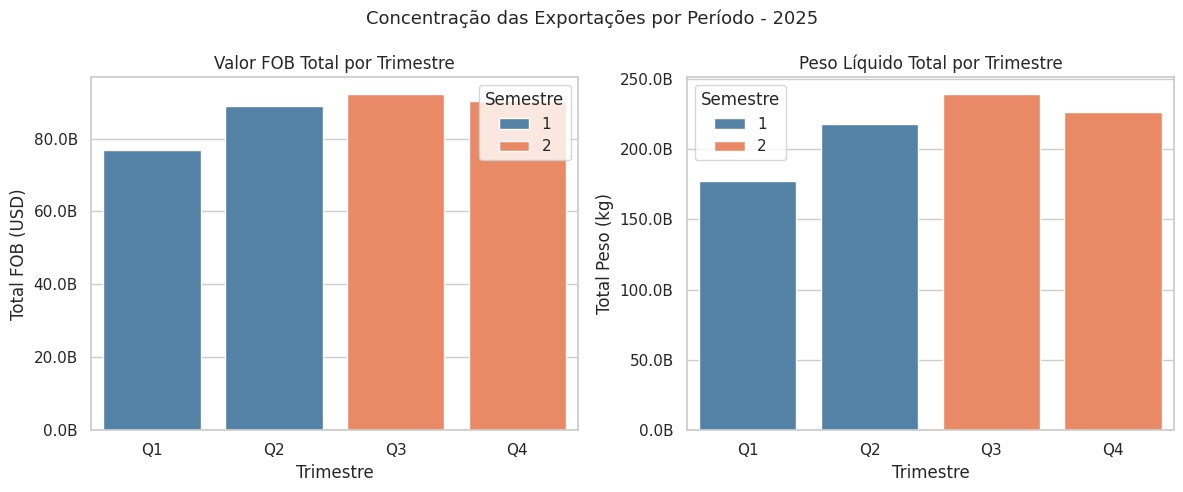

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

q5['quarter_label'] = q5['quarter'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

sns.barplot(data=q5, x='quarter_label', y='total_fob_usd', hue='semester',
            palette=['steelblue', 'coral'], ax=axes[0])
axes[0].set_title('Valor FOB Total por Trimestre')
axes[0].set_xlabel('Trimestre')
axes[0].set_ylabel('Total FOB (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[0].legend(title='Semestre')

sns.barplot(data=q5, x='quarter_label', y='total_weight_kg', hue='semester',
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Peso Líquido Total por Trimestre')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Total Peso (kg)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].legend(title='Semestre')

plt.suptitle('Concentração das Exportações por Período - 2025', fontsize=13)
plt.tight_layout()
plt.savefig('../results/q5_trimestre_semestre.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 5: Concentração por Trimestre e Semestre

Os dois gráficos de barras agrupadas por semestre (azul = 1º semestre, coral = 2º semestre) mostram que o Q1 tem os menores valores de FOB (~77 bilhões) e de peso (~175 bilhões de kg), enquanto Q3 apresenta os maiores (~92 bilhões em FOB e ~240 bilhões de kg). O 2º semestre acumula ligeiramente mais volume e valor que o 1º. A diferença entre Q1 e Q3 é de aproximadamente 20% tanto em valor quanto em peso.

Isso mostra que a concentração maior no segundo semestre, especialmente no Q3, é consistente com a H1 (Hipótese 1): o volume e o valor não se distribuem uniformemente entre os trimestres. O pico em Q3 (julho, agosto, setembro) corresponde ao período de maior exportação de soja e milho. A diferença mais expressiva entre Q1 e os demais trimestres mostra que o início do ano é o período de menor atividade exportadora em 2025, complementando o padrão mensal identificado na Consulta 1.

### Consulta 6 - Anomalias por Estado de Origem

Estados com valor FOB médio acima de 2× a mediana nacional. São potenciais exportadores de alto valor agregado ou outliers geográficos.

In [20]:
q6 = duckdb.sql(f"""
    WITH state_stats AS (
        SELECT
            origin_state,
            origin_region,
            COUNT(*)                AS n_records,
            MEDIAN(fob_value_usd)   AS median_fob_usd
        FROM '{PARQUET_PATH}'
        GROUP BY origin_state, origin_region
    ),
    national_median AS (
        SELECT MEDIAN(fob_value_usd) AS nat_median
        FROM '{PARQUET_PATH}'
    )
    SELECT
        s.*,
        n.nat_median,
        s.median_fob_usd / n.nat_median AS ratio_to_national
    FROM state_stats s, national_median n
    ORDER BY s.median_fob_usd DESC
""").df()

anomalias = q6[q6['ratio_to_national'] > 2].copy()
print(f'Estados com median_fob > 2× mediana nacional: {len(anomalias)}')
anomalias[['origin_state', 'origin_region', 'median_fob_usd', 'ratio_to_national', 'n_records']]

Estados com median_fob > 2× mediana nacional: 12


,origin_state,origin_region,median_fob_usd,ratio_to_national,n_records
0,MT,Central-West,128521.0,168.001307,9403
1,PI,Northeast,109524.5,143.169281,704
2,TO,North,109354.5,142.947059,2064
3,RO,North,76810.0,100.405229,3771
4,MS,Central-West,54793.0,71.624837,9926
5,RN,Northeast,29819.0,38.979085,2595
6,GO,Central-West,26670.5,34.863399,15684
7,PB,Northeast,18776.5,24.544444,1298
8,AC,North,17711.0,23.151634,745
9,DF,Central-West,16182.0,21.152941,2087


/tmp/ipykernel_70509/1787259347.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q6_sorted, y='origin_state', x='median_fob_usd', palette=palette, ax=ax)


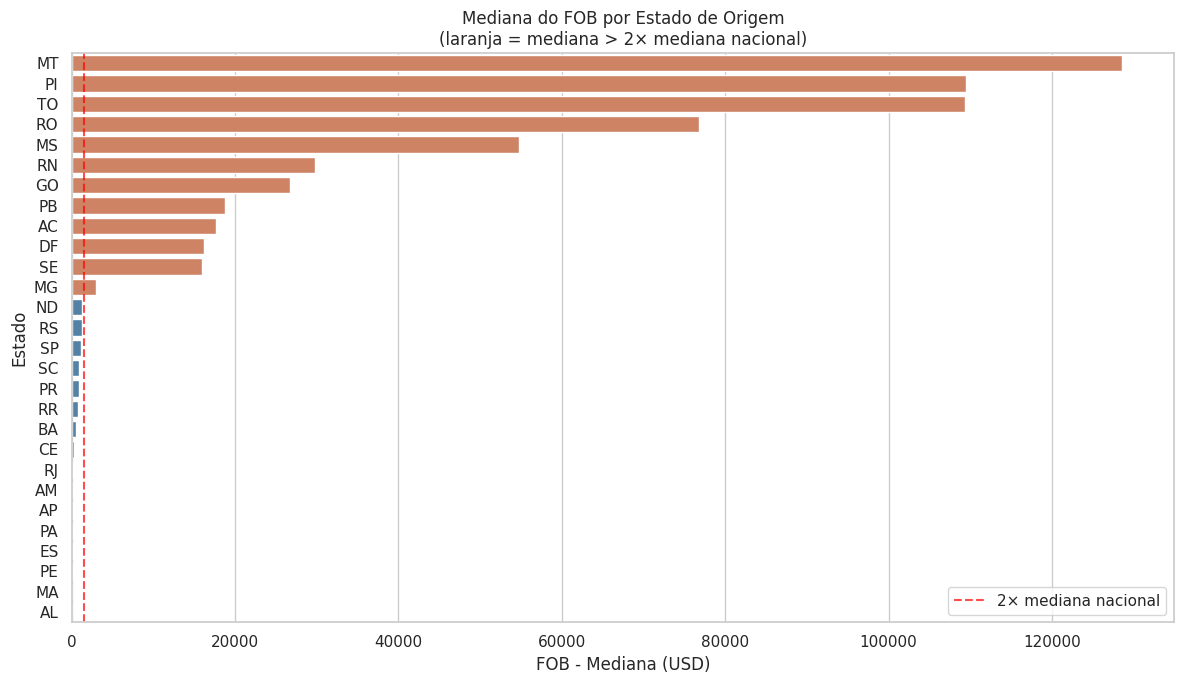

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

q6_sorted = q6.sort_values('median_fob_usd', ascending=False)
palette = ['#e07b54' if r > 2 else 'steelblue' for r in q6_sorted['ratio_to_national']]
sns.barplot(data=q6_sorted, y='origin_state', x='median_fob_usd', palette=palette, ax=ax)
ax.axvline(q6_sorted['nat_median'].iloc[0] * 2, color='red', linestyle='--',
           alpha=0.7, label='2× mediana nacional')
ax.set_title('Mediana do FOB por Estado de Origem\n(laranja = mediana > 2× mediana nacional)')
ax.set_xlabel('FOB - Mediana (USD)')
ax.set_ylabel('Estado')
ax.legend()
plt.tight_layout()
plt.savefig('../results/q6_anomalias_estado.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Consulta 6: Anomalias por Estado de Origem

Os estados em laranja têm mediana de FOB acima de 2× a mediana nacional. Os estados do centro-oeste (MT, MS, GO) e norte (TO, RO, PA) lideram o ranking, ou seja, refletindo o perfil de exportação de commodities agrícolas e minerais em grandes lotes. Na parte inferior aparecem estados com pauta exportadora mais diversificada (SP, RS, SC). Pode-se afirmar, então, que a concentração de commodities específicas em certos estados gera padrões distintos de valor por exportação ao longo do ano.

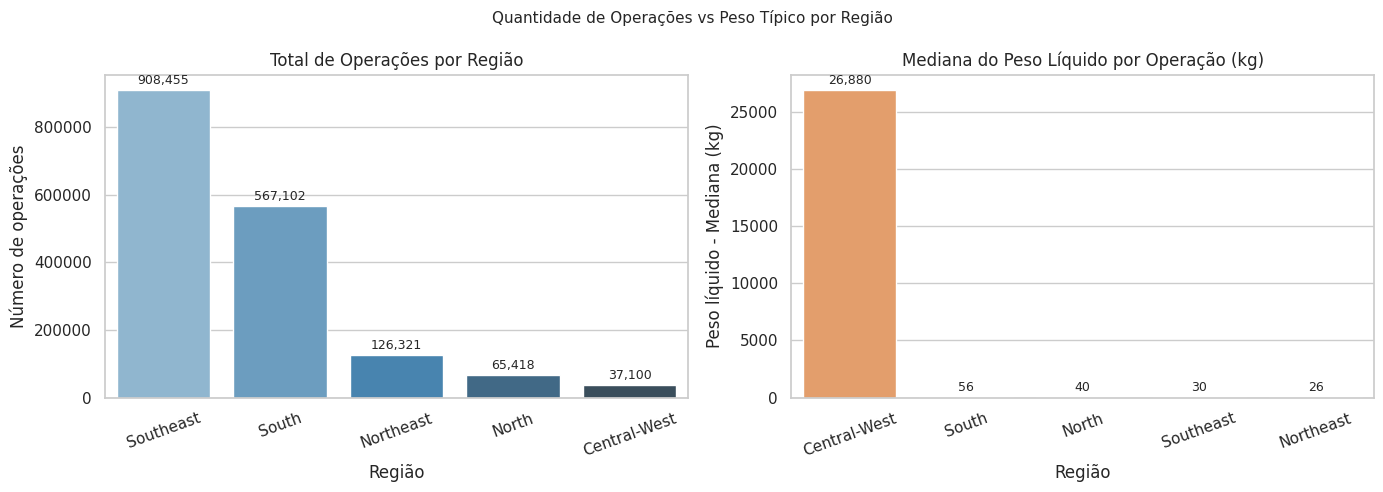

In [22]:
# Volume físico e número de operações por região de origem
q6_vol = duckdb.sql(f"""
    SELECT
        origin_region,
        COUNT(*)                  AS n_records,
        MEDIAN(net_weight_kg)     AS median_kg
    FROM '{PARQUET_PATH}'
    WHERE origin_region IS NOT NULL
    GROUP BY origin_region
""").df()

q6_vol['origin_region'] = q6_vol['origin_region'].astype(str)

df_ops    = q6_vol.sort_values('n_records', ascending=False).reset_index(drop=True)
df_weight = q6_vol.sort_values('median_kg', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: número de operações por região
ax1 = axes[0]
sns.barplot(
    data=df_ops, x='origin_region', y='n_records',
    hue='origin_region', palette='Blues_d', legend=False, ax=ax1
)
ax1.set_title('Total de Operações por Região')
ax1.set_xlabel('Região')
ax1.set_ylabel('Número de operações')
ax1.tick_params(axis='x', rotation=20)
for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_ops['n_records'].max() * 0.01,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

# Direita: mediana do peso líquido por operação
ax2 = axes[1]
sns.barplot(
    data=df_weight, x='origin_region', y='median_kg',
    hue='origin_region', palette='Oranges_d', legend=False, ax=ax2
)
ax2.set_title('Mediana do Peso Líquido por Operação (kg)')
ax2.set_xlabel('Região')
ax2.set_ylabel('Peso líquido - Mediana (kg)')
ax2.tick_params(axis='x', rotation=20)
for bar in ax2.patches:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_weight['median_kg'].max() * 0.01,
        f'{bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=9
    )

plt.suptitle(
    'Quantidade de Operações vs Peso Típico por Região',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../results/q6_volume_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Volume e Peso por Região de Origem

O gráfico da esquerda confirma que a região sudeste concentra a maior parte das operações de exportação, seguido pelo sul. Centro-oeste e norte tem participação muito menor em número de registros. O gráfico da direita inverte essa lógica: o centro-oeste apresenta a maior mediana de peso líquido por operação, ou seja, a exportação típica dessa região é fisicamente mais pesada do que em qualquer outra.

O centro-oeste exporta predominantemente commodities agrícolas a granel (soja de MT e MS, carne bovina de GO e MS), embarcadas em lotes de alto peso unitário. O sudeste, com pauta diversificada (manufaturados, químicos, produtos industriais de menor densidade) realiza muito mais operações, mas individualmente menores. O resultado é que a região sudeste domina em quantidade de operações e valor total, enquanto o centro-oeste domina quando se trata de peso líquido.

Assim, para a H2, esse contraste reforça que `net_weight_kg` (peso líquido do produto) e `origin_region` (origem da exportação) estão correlacionados. Cargas pesadas do centro-oeste tendem a seguir rotas marítimas ou rodoviárias em lotes concentrados, enquanto sudeste apresenta maior diversidade modal. A variável `origin_region` não é apenas geográfica, ela define indiretamente o perfil físico e logístico da carga.

## Análise Exploratória Estatística

In [23]:
df['transport_name'] = df['transport_route'].map(TRANSPORT_NAMES)
df['month_name'] = pd.Categorical(df['month_name'], categories=MONTH_ORDER, ordered=True)

df_main = df[df['transport_name'].isin(main_routes)].copy()
df_main_pos = df_main[(df_main['net_weight_kg'] > 0) & (df_main['fob_value_usd'] > 0)].copy()

print(f'df_main: {len(df_main):,} registros  |  df_main_pos: {len(df_main_pos):,} registros')

df_main: 1,691,376 registros  |  df_main_pos: 1,564,207 registros


### Análise Univariada

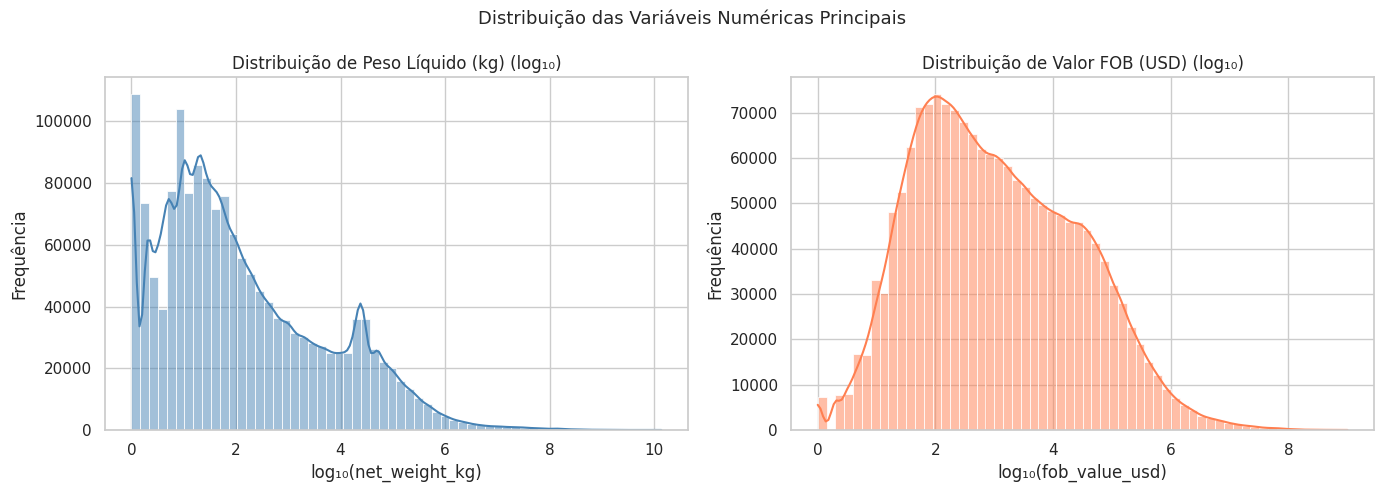

In [24]:
# Distribuições de net_weight_kg e fob_value_usd (escala log — dados altamente assimétricos)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
    axes,
    ['net_weight_kg', 'fob_value_usd'],
    ['Peso Líquido (kg)', 'Valor FOB (USD)'],
    ['steelblue', 'coral']
):
    data = df[df[col] > 0][col]
    sns.histplot(np.log10(data), kde=True, bins=60, color=color, ax=ax)
    ax.set_title(f'Distribuição de {label} (log₁₀)')
    ax.set_xlabel(f'log₁₀({col})')
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_uni_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
print('Estatísticas descritivas (variáveis numéricas contínuas):')
df[['net_weight_kg', 'fob_value_usd', 'value_per_kg']].describe().round(2)

Estatísticas descritivas (variáveis numéricas contínuas):


,net_weight_kg,fob_value_usd,value_per_kg
count,1.709746e+06,1.709746e+06,1578906.00
mean,5.028979e+05,2.037019e+05,339.29
std,3.858018e+07,4.784208e+06,52763.70
min,0.000000e+00,0.000000e+00,0.00
25%,5.000000e+00,8.800000e+01,2.78
50%,3.900000e+01,7.650000e+02,8.92
75%,8.850000e+02,1.155000e+04,35.00
max,1.369865e+10,1.009546e+09,53039197.00


### Interpretação - Distribuição das Variáveis Numéricas

Os dois histogramas com curva de densidade apresentam as distribuições de `net_weight_kg` e `fob_value_usd` em escala logarítmica (base 10). O peso líquido (gráfico da esquerda/azul) exibe um primeiro pico entre log₁₀ = 0 e log₁₀ = 1 (equivalente a 1–10 kg, cargas pequenas como encomendas aéreas e postais) e um segundo pico menor em torno de log₁₀ = 4 (equivalente a ~10.000 kg, grandes embarques marítimos) finalizando com uma cauda longa ao final à direita. O valor FOB (direita/coral) apresenta distribuição com pico principal em torno de log₁₀ = 2 (USD 100), e também com uma cauda longa à direita.

A bimodalidade do peso indica que existem dois perfis operacionais distintos no dataset: operações pequenas (provavelmente aéreas e postais, no primeiro pico) e grandes cargas a granel (provavelmente marítimas, no segundo pico). Essa separação natural é um indício de que `net_weight_kg` pode ser um discriminador entre as modalidades de via de transportes, o que é relevante para a H2.

/tmp/ipykernel_70509/1038906444.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=transport_counts, y='transport_name', x='n_records', palette='Blues_r', ax=ax)


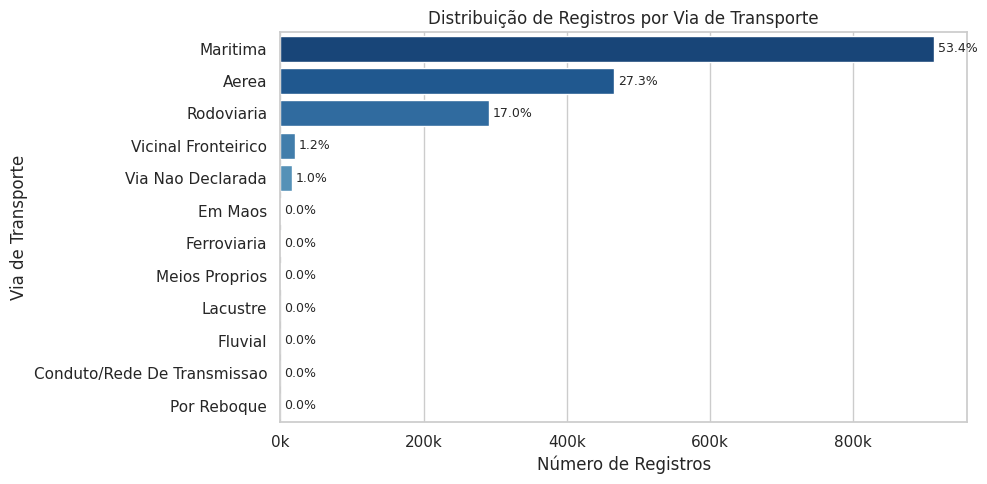

In [26]:
transport_counts = df['transport_name'].value_counts().reset_index()
transport_counts.columns = ['transport_name', 'n_records']
transport_counts['pct'] = (transport_counts['n_records'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=transport_counts, y='transport_name', x='n_records', palette='Blues_r', ax=ax)
for i, row in transport_counts.iterrows():
    ax.text(row['n_records'] + 5000, i, f"{row['pct']}%", va='center', fontsize=9)
ax.set_title('Distribuição de Registros por Via de Transporte')
ax.set_xlabel('Número de Registros')
ax.set_ylabel('Via de Transporte')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('../results/eda_uni_transport.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Distribuição por Via de Transporte

O gráfico de barras horizontais exibe a contagem de registros por via de transporte com o percentual indicado ao final de cada barra. A marítima domina com 53,4% das operações, seguida pela aérea (27,3%) e rodoviária (17,0%). Os demais, somados, representam menos de 3%.

Esse forte desbalanceamento entre classes pode ter impacto direto na modelagem proposta pela Pergunta 2. Um classificador que sempre predisse "marítima" já acertaria mais da metade dos casos.

/tmp/ipykernel_70509/1979139398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_counts, x='origin_region', y='count', palette='muted', ax=axes[0])
/tmp/ipykernel_70509/1979139398.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quarter_counts, x='quarter_label', y='count', palette='muted', ax=axes[1])


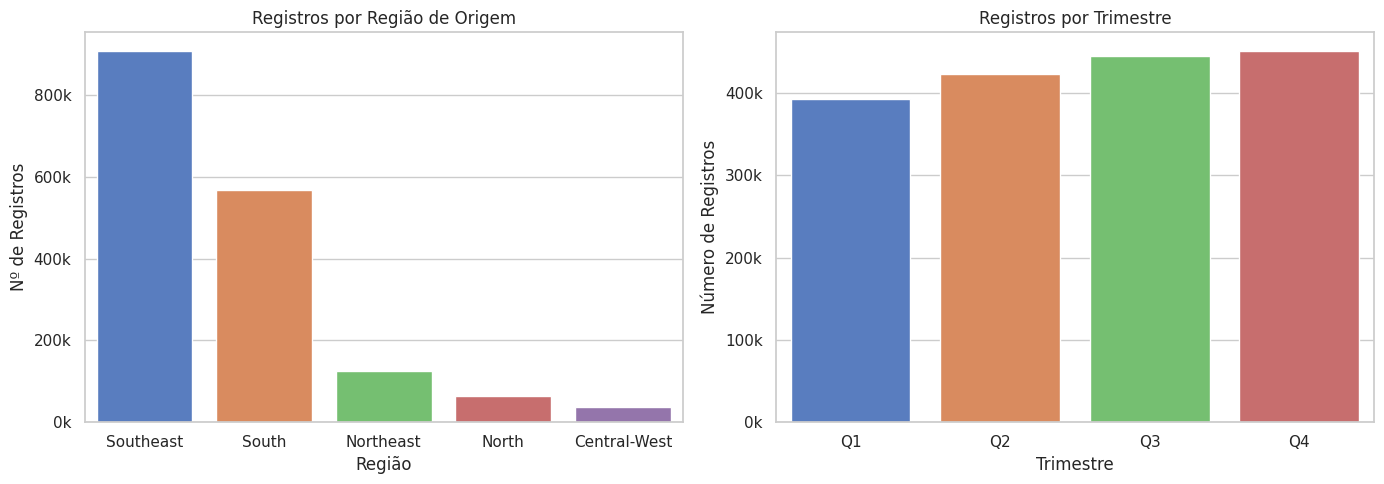

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_counts = df['origin_region'].value_counts().reset_index()
region_counts.columns = ['origin_region', 'count']
sns.barplot(data=region_counts, x='origin_region', y='count', palette='muted', ax=axes[0])
axes[0].set_title('Registros por Região de Origem')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Nº de Registros')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

quarter_counts = df['quarter'].value_counts().sort_index().reset_index()
quarter_counts.columns = ['quarter', 'count']
quarter_counts['quarter_label'] = quarter_counts['quarter'].map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
sns.barplot(data=quarter_counts, x='quarter_label', y='count', palette='muted', ax=axes[1])
axes[1].set_title('Registros por Trimestre')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Número de Registros')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.savefig('../results/eda_uni_region_quarter.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Registros por Região e Trimestre

O gráfico da esquerda mostra que sudeste concentra a maior parte dos registros, seguido pelo Sul. Nordeste, Norte e Centro-Oeste tem participação bem menor. O sudeste tem sozinho quase o dobro do sul. O gráfico da direita mostra a distribuição entre trimestres: relativamente equilibrada, mas com Q1 levemente inferior e Q3/Q4 com ligeiramente mais operações.

A dominância do sudeste e sul em número de operações reflete a concentração de infraestrutura portuária e industrial nessas regiões. Para a H2, isso indica que `origin_region` tem distribuição desbalanceada. O leve crescimento de operações nos trimestres Q3 e Q4 é consistente com o padrão sazonal identificado na primeira consulta (Consulta 1) e apoia a H1.

### Análise Bivariada

/tmp/ipykernel_70509/953682641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main_pos, x='transport_name', y='net_weight_kg',


/tmp/ipykernel_70509/953682641.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main_pos, x='transport_name', y='fob_value_usd',


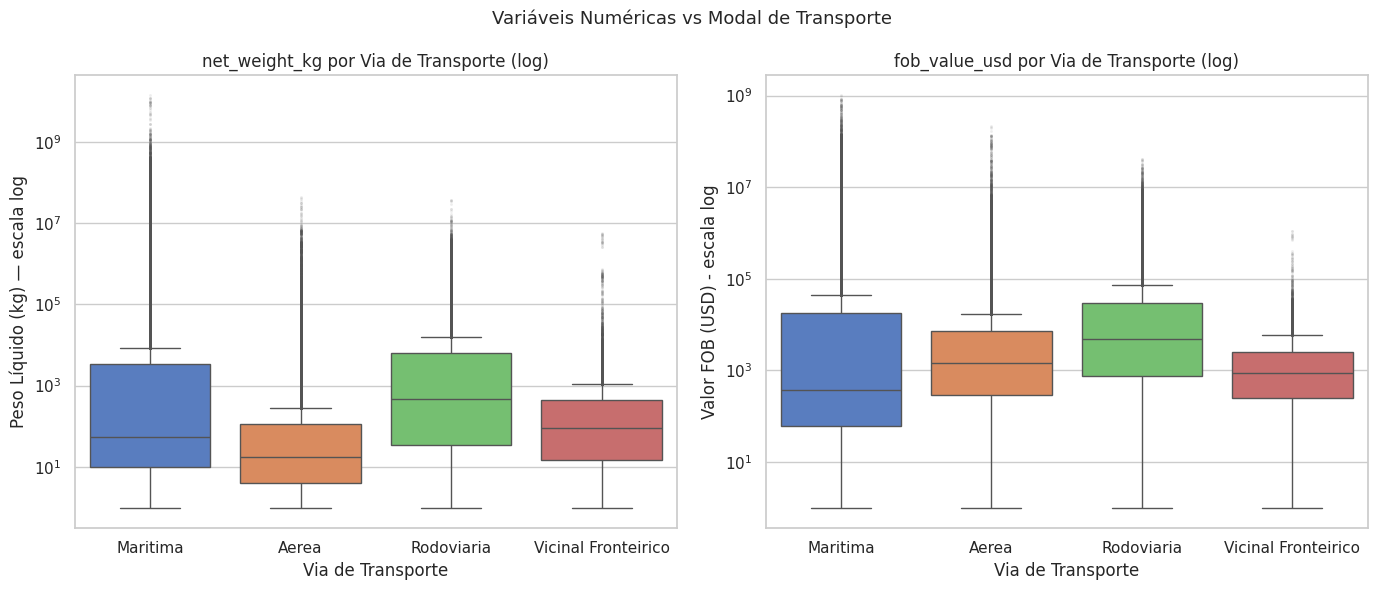

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_main_pos, x='transport_name', y='net_weight_kg',
            order=main_routes, palette='muted', ax=axes[0],
            flierprops=dict(marker='.', alpha=0.1, markersize=2))
axes[0].set_yscale('log')
axes[0].set_title('net_weight_kg por Via de Transporte (log)')
axes[0].set_xlabel('Via de Transporte')
axes[0].set_ylabel('Peso Líquido (kg) — escala log')

sns.boxplot(data=df_main_pos, x='transport_name', y='fob_value_usd',
            order=main_routes, palette='muted', ax=axes[1],
            flierprops=dict(marker='.', alpha=0.1, markersize=2))
axes[1].set_yscale('log')
axes[1].set_title('fob_value_usd por Via de Transporte (log)')
axes[1].set_xlabel('Via de Transporte')
axes[1].set_ylabel('Valor FOB (USD) - escala log')

plt.suptitle('Variáveis Numéricas vs Modal de Transporte', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_biv_boxplots_transport.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Variáveis Numéricas vs Modal de Transporte

Os boxplots em escala logarítmica comparam `net_weight_kg` (esquerda) e `fob_value_usd` (direita) entre os quatro principais vias de transporte. Para o peso líquido: a via marítima apresenta a maior mediana e a maior IQR, indicando cargas consistentemente mais pesadas e maior variabilidade. A rodoviária fica em segundo lugar, a aérea tem a menor mediana de peso. Para o valor FOB: a via rodoviária e a aérea apresentam medianas maiores do que a marítima.

As distribuições claramente distintas entre as modalidades confirmam que `net_weight_kg` e `fob_value_usd` pdem ser boas features para a classificação do modal de transporte. Isso fornece suporte para a H2 e impacta diretamente a Pergunta 2.

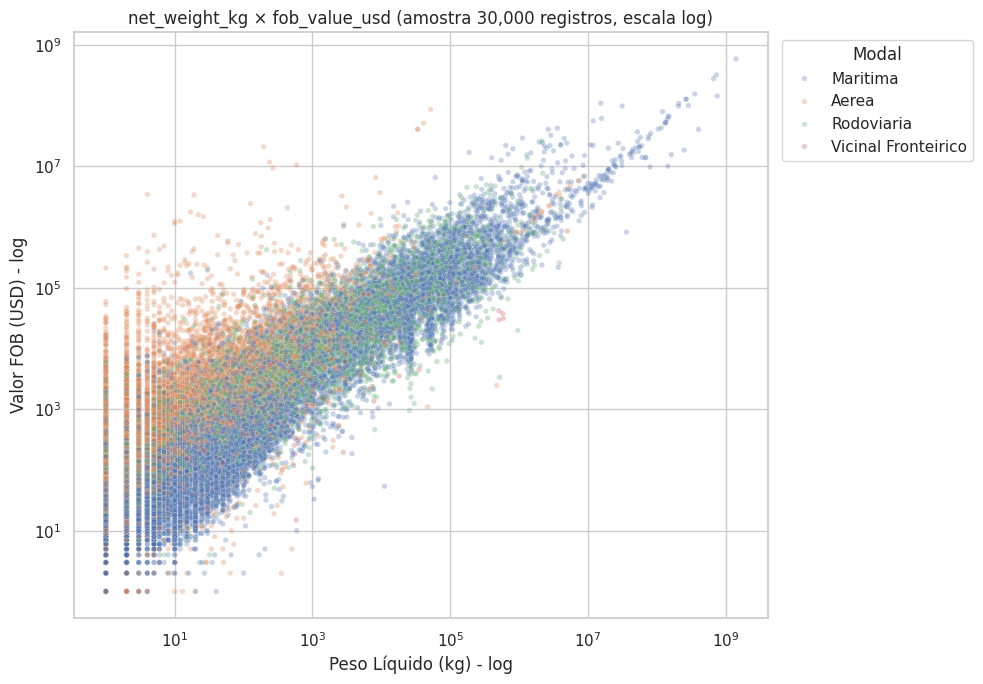

In [29]:
# Amostra para scatter (performance)
SAMPLE_N = 30_000
df_sample = df_main_pos.sample(n=min(SAMPLE_N, len(df_main_pos)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=df_sample,
    x='net_weight_kg',
    y='fob_value_usd',
    hue='transport_name',
    hue_order=main_routes,
    alpha=0.3,
    s=15,
    ax=ax
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(f'net_weight_kg × fob_value_usd (amostra {SAMPLE_N:,} registros, escala log)')
ax.set_xlabel('Peso Líquido (kg) - log')
ax.set_ylabel('Valor FOB (USD) - log')
ax.legend(title='Modal', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/eda_biv_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Relação entre Peso e Valor FOB por Modal

O gráfico de dispersão revela uma correlação positiva entre peso líquido e valor FOB em todos os modais: quanto maior o peso, maior tende a ser o valor. Os pontos formam um rastro diagonal ascendente. A marítima (azul) ocupa preferencialmente a região de maior peso (parte mais à direita do eixo X). A aérea (laranja/coral) e a rodoviária (verde) aparecem mais distribuídas em toda a faixa. Há uma concentração de pontos em forma de barra vertical no extremo esquerdo, correspondendo a operações com peso mínimo.

A sobreposição entre classes na região central indica que nenhum preditor isolado classificará o modal com alta precisão. Contudo, a separação nos extremos sustenta a viabilidade de um modelo classificador para a Pergunta 2. A correlação positiva clara entre peso e FOB é consistente, e reforça que cargas mais pesadas (geralmente commodities a granel) geram maior receita total.

/tmp/ipykernel_70509/2175507499.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_fob, x='origin_region', y='median_fob_usd', palette='Blues_r', ax=ax)


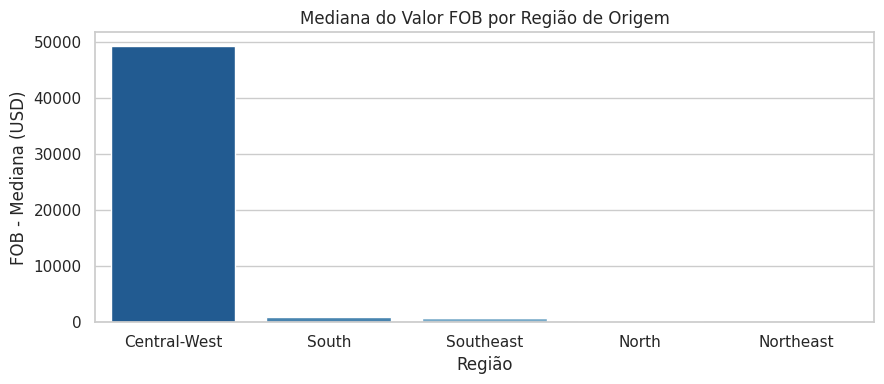

In [30]:
region_fob = df.groupby('origin_region', observed=True)['fob_value_usd'].median().reset_index()
region_fob.columns = ['origin_region', 'median_fob_usd']
region_fob = region_fob.sort_values('median_fob_usd', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=region_fob, x='origin_region', y='median_fob_usd', palette='Blues_r', ax=ax)
ax.set_title('Mediana do Valor FOB por Região de Origem')
ax.set_xlabel('Região')
ax.set_ylabel('FOB - Mediana (USD)')
plt.tight_layout()
plt.savefig('../results/eda_biv_region_fob.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Mediana do Valor FOB por Região de Origem

O centro-oeste apresenta a maior mediana, seguida pela região norte. As demais regiões têm medianas menores e mais próximas entre si.

O centro-oeste exporta, principalmente, commodities agrícolas em lotes concentrados, o que resulta em uma mediana de FOB genuinamente mais alta. Já sudeste e sul têm pauta diversificada com muitas operações de menor valor, reduzindo a mediana.

### Análise Multivariada

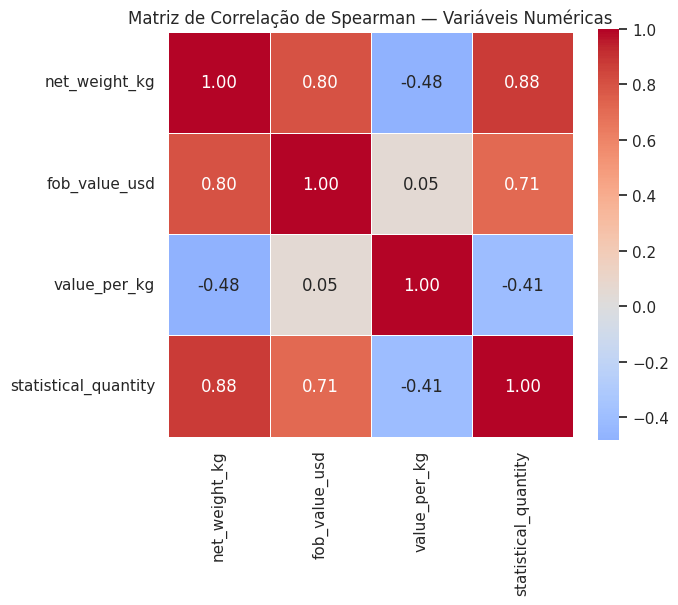

In [31]:
num_cols = ['net_weight_kg', 'fob_value_usd', 'value_per_kg', 'statistical_quantity']
df_num = df[num_cols].copy()

corr = df_num.corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação de Spearman — Variáveis Numéricas')
plt.tight_layout()
plt.savefig('../results/eda_multi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Matriz de Correlação de Spearman

A alta correlação entre peso e FOB (0,80) indica possível redundância se ambas as variáveis forem usadas simultaneamente como preditores na Pergunta 2. Para a H2, `value_per_kg` é uma feature interessante por capturar uma dimensão diferente (o valor unitário da mercadoria) que distingue bem cargas de alto valor agregado  das commodities a granel.

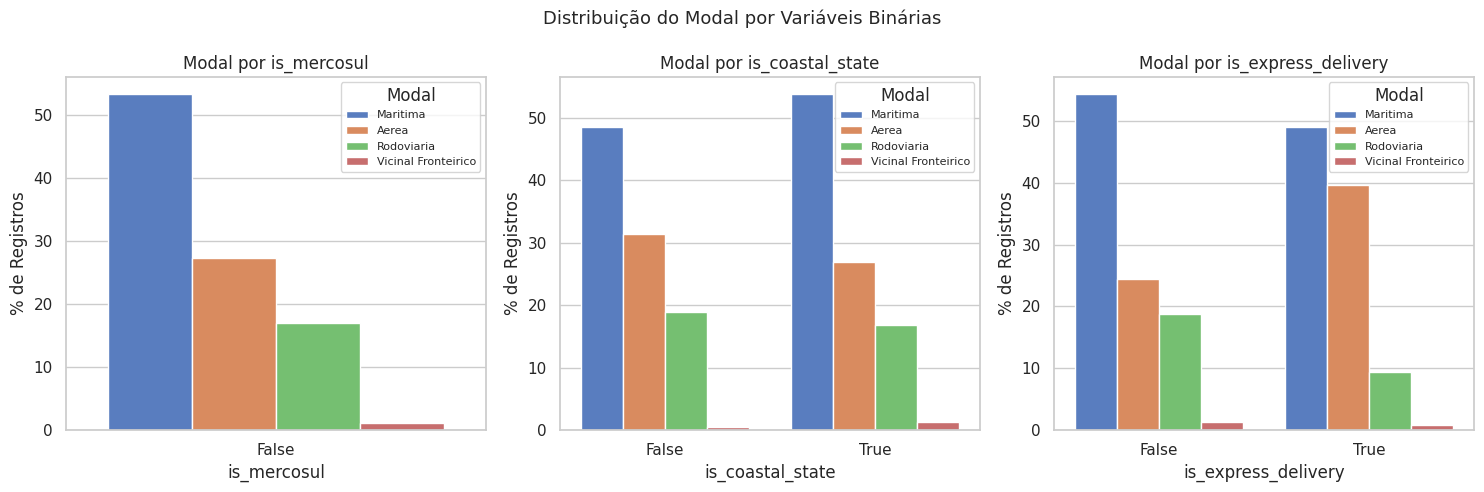

In [32]:
flag_cols = ['is_mercosul', 'is_coastal_state', 'is_express_delivery']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, flag in zip(axes, flag_cols):
    ct = df.groupby([flag, 'transport_name'], observed=True).size().reset_index(name='count')
    ct_pct = ct.copy()
    ct_pct['pct'] = ct.groupby(flag)['count'].transform(lambda x: x / x.sum() * 100)
    ct_top = ct_pct[ct_pct['transport_name'].isin(main_routes)]

    sns.barplot(data=ct_top, x=flag, y='pct', hue='transport_name',
                hue_order=main_routes, palette='muted', ax=ax)
    ax.set_title(f'Modal por {flag}')
    ax.set_xlabel(flag)
    ax.set_ylabel('% de Registros')
    ax.legend(title='Modal', fontsize=8)

plt.suptitle('Distribuição do Modal por Variáveis Binárias', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_multi_flags.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - Modal por Variáveis Binárias

O painel da esquerda (`is_mercosul`) revela o efeito mais marcante: quando o destino é um país do Mercosul (`True`), o modal rodoviário salta para ~77% das operações, contra apenas ~10% para destinos não-Mercosul. A marítima cai de ~60% para ~1%. O gráfico central (`is_coastal_state`) mostra diferença menor: estados costeiros têm ligeiramente mais marítima (~55%) do que não-costeiros (~49%), com aérea sendo mais presente em estados não-costeiros (~32%). Na ilustração da direita (`is_express_delivery`), quando o registro é de entrega expressa (`True`), o modal aéreo sobe de ~24% para ~40%, com redução correspondente da rodoviária.

O painel do Mercosul é o resultado mais expressivo: a variável `is_mercosul` altera completamente o perfil de modalidades, com predominância rodoviária para destinos do bloco. 

## Teste de Hipóteses

Verificação preliminar das hipóteses levantadas na Seção 1, utilizando testes não-paramétricos (dados assimétricos, não normais).

### H1 - Sazonalidade

Hipótese: `net_weight_kg` e `fob_value_usd` apresentam picos de concentração significativos em meses específicos.

Teste: Kruskal-Wallis, testa se pelo menos um mês tem distribuição significativamente diferente dos demais.

In [33]:
groups_weight = [grp['net_weight_kg'].values for _, grp in df.groupby('month', observed=True)]
groups_fob    = [grp['fob_value_usd'].values for _, grp in df.groupby('month', observed=True)]

stat_w, p_w = stats.kruskal(*groups_weight)
stat_f, p_f = stats.kruskal(*groups_fob)

print('=== Teste Kruskal-Wallis ===')
print(f'net_weight_kg: H={stat_w:.2f}, p={p_w:.2e}')
print(f'fob_value_usd: H={stat_f:.2f}, p={p_f:.2e}')

alpha = 0.05
for label, p in [('net_weight_kg', p_w), ('fob_value_usd', p_f)]:
    resultado = 'REJEITA H0 (diferença significativa entre meses)' if p < alpha else 'NÃO rejeita H0'
    print(f'{label}: {resultado} (α={alpha})')

=== Teste Kruskal-Wallis ===
net_weight_kg: H=547.58, p=2.24e-110
fob_value_usd: H=493.63, p=7.32e-99
net_weight_kg: REJEITA H0 (diferença significativa entre meses) (α=0.05)
fob_value_usd: REJEITA H0 (diferença significativa entre meses) (α=0.05)


/tmp/ipykernel_70509/4006086729.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='month_name', y='median_weight', palette='Blues', ax=axes[0])
/tmp/ipykernel_70509/4006086729.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='month_name', y='median_fob', palette='Oranges', ax=axes[1])


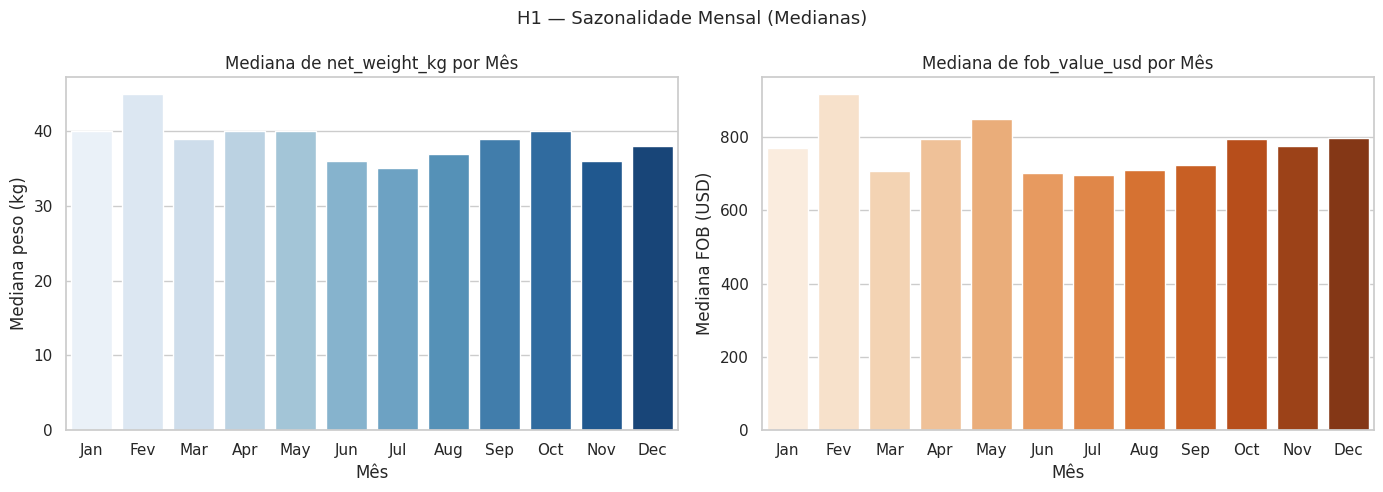

In [34]:
monthly = df.groupby(['month', 'month_name'], observed=True).agg(
    median_weight=('net_weight_kg', 'median'),
    median_fob=('fob_value_usd', 'median')
).reset_index().sort_values('month')
monthly['month_name'] = pd.Categorical(monthly['month_name'], categories=MONTH_ORDER, ordered=True)
monthly = monthly.sort_values('month_name')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=monthly, x='month_name', y='median_weight', palette='Blues', ax=axes[0])
axes[0].set_title('Mediana de net_weight_kg por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Mediana peso (kg)')

sns.barplot(data=monthly, x='month_name', y='median_fob', palette='Oranges', ax=axes[1])
axes[1].set_title('Mediana de fob_value_usd por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Mediana FOB (USD)')

plt.suptitle('H1 — Sazonalidade Mensal (Medianas)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/h1_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação - H1: Sazonalidade

O teste de Kruskal-Wallis rejeitou H0 para ambas as variáveis com p < 0,05, confirmando que há diferença estatisticamente significativa entre pelo menos dois meses do ano.


### H2 - Importância dos Preditores para transport_route

Hipótese: `net_weight_kg` e `origin_state` têm maior associação com `transport_route` do que `fob_value_usd`.

- **Preditores categóricos:** V de Cramér
- **Preditores numéricos:** correlação de Spearman entre `transport_route` e cada variável numérica

In [35]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = stats.chi2_contingency(ct, correction=False)
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - (k - 1) ** 2 / (n - 1)
    r_corr = r - (r - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

cat_predictors = ['origin_state', 'origin_region', 'ncm_chapter']
cramers_results = {}
for col in cat_predictors:
    v = cramers_v(df['transport_route'], df[col])
    cramers_results[col] = round(v, 4)
    print(f'V de Cramér (transport_route × {col}): {v:.4f}')

V de Cramér (transport_route × origin_state): 0.1451


V de Cramér (transport_route × origin_region): 0.1626
V de Cramér (transport_route × ncm_chapter): 0.2029


In [36]:
df['transport_route_int'] = pd.to_numeric(df['transport_route'], errors='coerce')

num_predictors = ['net_weight_kg', 'fob_value_usd', 'value_per_kg']
spearman_results = {}
for col in num_predictors:
    sub = df[['transport_route_int', col]].dropna()
    rho, p = stats.spearmanr(sub['transport_route_int'], sub[col])
    spearman_results[col] = round(abs(rho), 4)
    print(f'Spearman |ρ| (transport_route × {col}): {abs(rho):.4f}  (p={p:.2e})')

Spearman |ρ| (transport_route × net_weight_kg): 0.0292  (p=0.00e+00)


Spearman |ρ| (transport_route × fob_value_usd): 0.1711  (p=0.00e+00)


Spearman |ρ| (transport_route × value_per_kg): 0.3258  (p=0.00e+00)


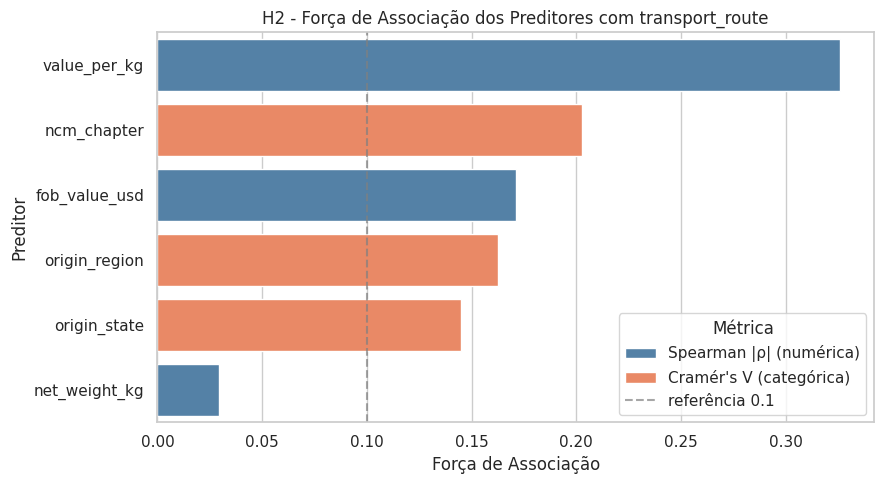


Ranking de associação com transport_route:
    predictor                    type  association
 value_per_kg Spearman |ρ| (numérica)       0.3258
  ncm_chapter Cramér's V (categórica)       0.2029
fob_value_usd Spearman |ρ| (numérica)       0.1711
origin_region Cramér's V (categórica)       0.1626
 origin_state Cramér's V (categórica)       0.1451
net_weight_kg Spearman |ρ| (numérica)       0.0292


In [37]:
all_results = {**cramers_results, **spearman_results}
result_df = pd.DataFrame(list(all_results.items()), columns=['predictor', 'association'])
result_df['type'] = result_df['predictor'].apply(
    lambda x: "Cramér's V (categórica)" if x in cat_predictors else 'Spearman |ρ| (numérica)'
)
result_df = result_df.sort_values('association', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=result_df, y='predictor', x='association',
            hue='type', dodge=False, palette=['steelblue', 'coral'], ax=ax)
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.7, label='referência 0.1')
ax.set_title('H2 - Força de Associação dos Preditores com transport_route')
ax.set_xlabel('Força de Associação')
ax.set_ylabel('Preditor')
ax.legend(title='Métrica')
plt.tight_layout()
plt.savefig('../results/h2_associacao_preditores.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRanking de associação com transport_route:')
print(result_df[['predictor', 'type', 'association']].to_string(index=False))

### Interpretação - H2: Força de Associação dos Preditores com `transport_route`

Os resultados contradizem parcialmente H2. Embora `origin_state` e `origin_region` tenham associação relevante com o modal (acima da referência de 0,10), o `net_weight_kg` apontado na hipótese como o principal preditor físico, apresentou a menor associação de todos os preditores testados. O preditor dominante foi `value_per_kg`, e `fob_value_usd` superou individualmente as variáveis geográficas. Portanto, H2 é refutada parcialmente.